---
***Markdown explaining the contents and purpose***
---

In [35]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Import Class
from pathlib import Path

# Set Path to current working directory
cwd = Path.cwd()

# Set filesystem paths
ROOT = cwd.parent if cwd.name == "notebooks" else cwd

# Establish paths
ROOT

DATA_RAW = ROOT / "data" / "raw"

DATA_PROCESSED = ROOT / "data" / "processed"

FIGURES = ROOT / "figures"

# Set scope in years of available data
YEAR_MIN = 2015
YEAR_MAX = 2023

In [36]:
# Verify all paths
print("ROOT:", ROOT)
print("RAW DATA:", DATA_RAW)
print("PROCESSED DATA:", DATA_PROCESSED)
print("FIGURES:", FIGURES)

ROOT: /home/ggirelli/Documents/DataAnalysis/Projects/Capstone_1
RAW DATA: /home/ggirelli/Documents/DataAnalysis/Projects/Capstone_1/data/raw
PROCESSED DATA: /home/ggirelli/Documents/DataAnalysis/Projects/Capstone_1/data/processed
FIGURES: /home/ggirelli/Documents/DataAnalysis/Projects/Capstone_1/figures


In [37]:
# Load raw data
RAW_DEMOGRAPHIC_ASPECTS_FILE = DATA_RAW / "Demographic-aspects-2023.xlsx"

In [38]:
# Create "if statement" to test for errors
if not RAW_DEMOGRAPHIC_ASPECTS_FILE.exists():
    raise FileNotFoundError

In [39]:
# Set variable for wide format
dem_raw_wide = pd.read_excel(RAW_DEMOGRAPHIC_ASPECTS_FILE, header=1)

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Key Demographic aspects  12 non-null     str    
 1   Unit                     10 non-null     str    
 2   2015                     11 non-null     float64
 3   2016                     11 non-null     float64
 4   2017                     11 non-null     float64
 5   2018                     11 non-null     float64
 6   2019                     11 non-null     float64
 7   2020                     11 non-null     float64
 8   2021                     11 non-null     float64
 9   2022                     11 non-null     float64
 10  2023                     11 non-null     float64
dtypes: float64(9), str(2)
memory usage: 1.4 KB


,2015,2016,2017,2018,2019,2020,2021,2022,2023
count,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000
mean,19910.690909,19835.836364,19768.709091,19931.618182,19900.227273,19554.563636,19569.909091,19527.600000,19669.081818
std,36552.487337,36676.860299,36642.663745,36775.589449,36829.397260,36454.365394,36236.378634,36121.861683,36223.424061
min,18.700000,-293.000000,-698.000000,18.300000,-436.000000,-1617.000000,-519.000000,-352.000000,15.600000
25%,38.200000,28.600000,29.100000,39.100000,30.250000,31.650000,32.350000,33.050000,41.750000
50%,89.500000,40.400000,40.700000,66.000000,41.500000,42.400000,42.900000,43.400000,88.700000
75%,26104.500000,26033.500000,26001.500000,26059.000000,26061.000000,25765.000000,25630.500000,25517.500000,25578.500000
max,108635.000000,108818.000000,108651.000000,109164.000000,109241.000000,107932.000000,107468.000000,107152.000000,107566.000000


---
**Inspect DataFrame**
---

In [ ]:
dem_raw_wide.describe()

In [ ]:
dem_raw_wide.info()

In [ ]:
dem_raw_wide.head()

In [40]:
columns = dem_raw_wide["Key Demographic aspects"]

# Inspect columns
columns

0                         Males
1                       Females
2              Total population
3                     Sex ratio
4             Pop. per km2 land
5     Pop. 14 years and younger
6       Pop. 60 years and older
7                   Average age
8                         Males
9                       Females
10                        Total
11                Net migration
Name: Key Demographic aspects, dtype: str

In [41]:
# Inspect and filter the data into our two groups
males = dem_raw_wide[dem_raw_wide["Key Demographic aspects"] == "Males"]
females = dem_raw_wide[dem_raw_wide["Key Demographic aspects"] == "Females"]

In [42]:
# Check males
males

,Key Demographic aspects,Unit,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Males,Absolute,51309.0,51462.0,51399.0,51512.0,51515.0,50930.0,50664.0,50440.0,50559.0


In [43]:
# Check females
females

,Key Demographic aspects,Unit,2015,2016,2017,2018,2019,2020,2021,2022,2023
1,Females,Absolute,57326.0,57357.0,57253.0,57652.0,57726.0,57002.0,56804.0,56712.0,57007.0


In [44]:
# Calculate the yearly change (slicing 2015 to 2023)
# Using.diff(axis=1) to subtract each year from the previous one
yearly_change_males_df = males.loc[:, 2015:2023].diff(axis=1)
yearly_change_females_df = females.loc[:, 2015:2023].diff(axis=1)

In [45]:
yearly_change_males_df

,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,NaN,153.0,-63.0,113.0,3.0,-585.0,-266.0,-224.0,119.0


In [46]:
yearly_change_females_df

,2015,2016,2017,2018,2019,2020,2021,2022,2023
1,NaN,31.0,-104.0,399.0,74.0,-724.0,-198.0,-92.0,295.0


---
**Note:** Annual change starts in **2016**. The **2015** value is undefined because no 2014 baseline is available.
**2015** has been removed in the cell below using **.droplevel(1)**
---

In [47]:
# Combine them into one comparison table
sex_comparison = pd.concat([yearly_change_males_df, yearly_change_females_df], keys=["Males", "Females"])

# Clean up: drop the extra index level
sex_comparison = sex_comparison.droplevel(1)

sex_comparison

,2015,2016,2017,2018,2019,2020,2021,2022,2023
Males,NaN,153.0,-63.0,113.0,3.0,-585.0,-266.0,-224.0,119.0
Females,NaN,31.0,-104.0,399.0,74.0,-724.0,-198.0,-92.0,295.0


In [48]:
# Convert values and assign new variables
sex_comparison.columns = sex_comparison.columns.astype(int)

years = sex_comparison.columns
yearly_change_males_values = sex_comparison.loc["Males"].values
yearly_change_females_values = sex_comparison.loc["Females"].values

In [49]:
years

Index([2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023], dtype='int64')

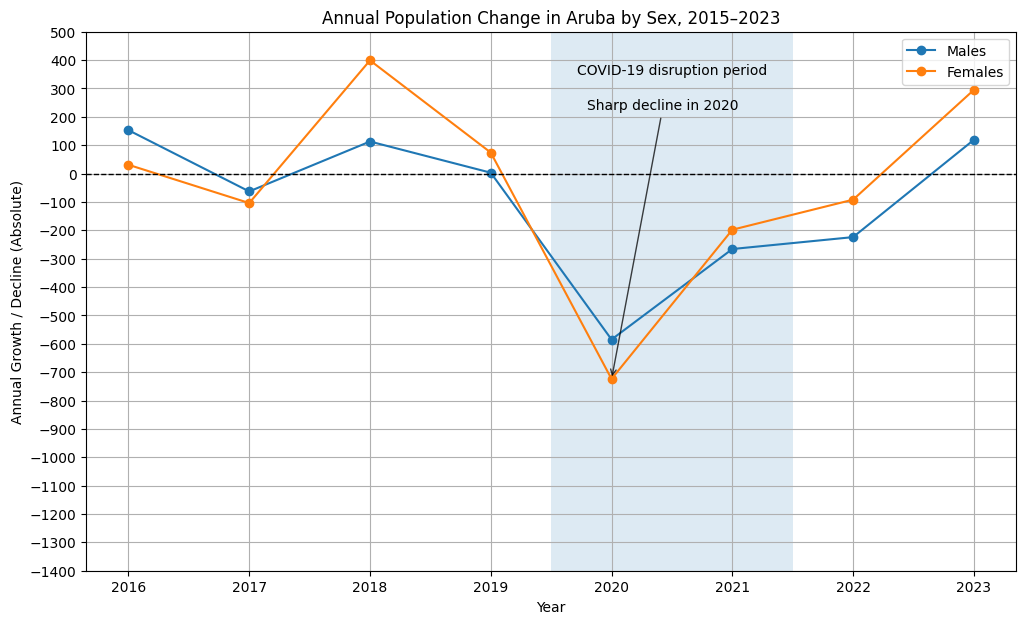

In [51]:
# Create plot
plt.figure(figsize=(12, 7))

# Main line graphs
plt.plot(years, yearly_change_males_values, marker="o", label="Males")
plt.plot(years, yearly_change_females_values, marker="o", label="Females")

# Ticks on y-axis
plt.yticks(np.arange(-1400, 501, 100))

# Zero baseline
plt.axhline(0, color="black", linestyle="--", linewidth=1)

# Added COVID label and shaded area for extra clarity
plt.text(2020.5, 350, "COVID-19 disruption period",
         ha="center", fontsize=10)
plt.axvspan(2019.5, 2021.5, alpha=0.15)

# Arrow (for added graphic design)
plt.annotate(
    "Sharp decline in 2020",
    xy=(2020, -725),
    xytext=(2019.8, 225),
    arrowprops=dict(arrowstyle="->", alpha=0.75)
)

# Title and legend
plt.title("Annual Population Change in Aruba by Sex, 2016–2023")
plt.xlabel("Year")
plt.ylabel("Annual Growth / Decline (Absolute)")
plt.grid(True)

plt.legend()

# Save figure
plt.savefig(FIGURES / "cbs_demographic_changes-2015-2023.png", dpi=300)

plt.show()